In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

In [28]:
# dataset
df = pd.read_csv(r"D:\MACHINE_LERNING_PROJECTS\DATA_diabetes_012_health_indicators\db\diabetes_012_health_indicators_BRFSS2015.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [20]:
df_size = df.size
df_size

5580960

In [29]:

# Valeurs manquantes
df.isnull().sum()

# Suppression simple si nécessaire
df = df.dropna()

# Vérification doublons
df.duplicated().sum()
df = df.drop_duplicates()

In [57]:
a = len(df)
a

229781

In [30]:
# Univariate Analysis

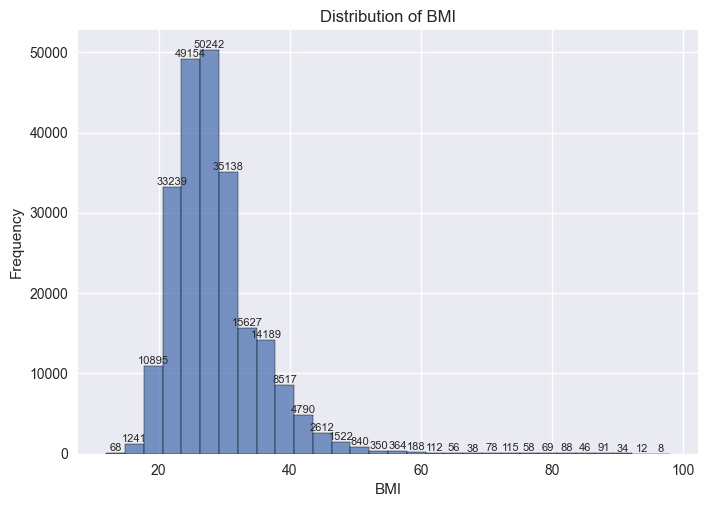

In [83]:
# Histogramme BMI

plt.figure()

ax = sns.histplot(df['BMI'], bins=30)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

# Ajouter les valeurs sur chaque barre
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha='center',
            va='bottom',
            fontsize=8
        )

fig_path = "D:/MACHINE_LERNING_PROJECTS/DATA_diabetes_012_health_indicators/outputs/figures"

plt.savefig(f"{fig_path}/bmi_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

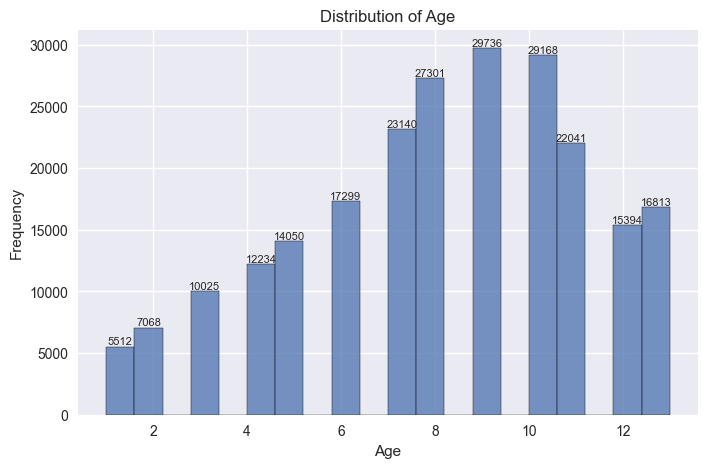

In [82]:
# Histogramme age
plt.figure(figsize=(8,5))

ax = sns.histplot(df['Age'], bins=20)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            int(height),
            ha='center',
            va='bottom',
            fontsize=8
        )
plt.savefig(f"{fig_path}/age_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

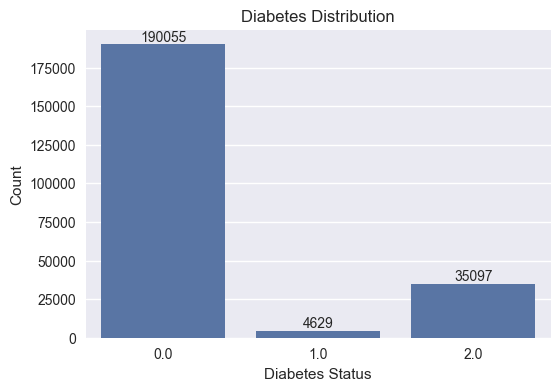

Diabetes_012
0.0    82.71
2.0    15.27
1.0     2.01
Name: proportion, dtype: float64

In [84]:
# Class Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Diabetes_012', data=df)

plt.title("Diabetes Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")

# Ajouter les valeurs sur les barres
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )
plt.savefig(f"{fig_path}/diabetes_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

(df['Diabetes_012'].value_counts(normalize=True) * 100).round(2)

In [59]:
print("len(df):", len(df))
print("sum countplot:", sum([p.get_height() for p in ax.patches]))
print("NaN:", df['Diabetes_012'].isnull().sum())
print(df['Diabetes_012'].value_counts(dropna=False))

len(df): 229781
sum countplot: 229781.0
NaN: 0
Diabetes_012
0.0    190055
2.0     35097
1.0      4629
Name: count, dtype: int64


In [37]:
# Bivariate Analysis

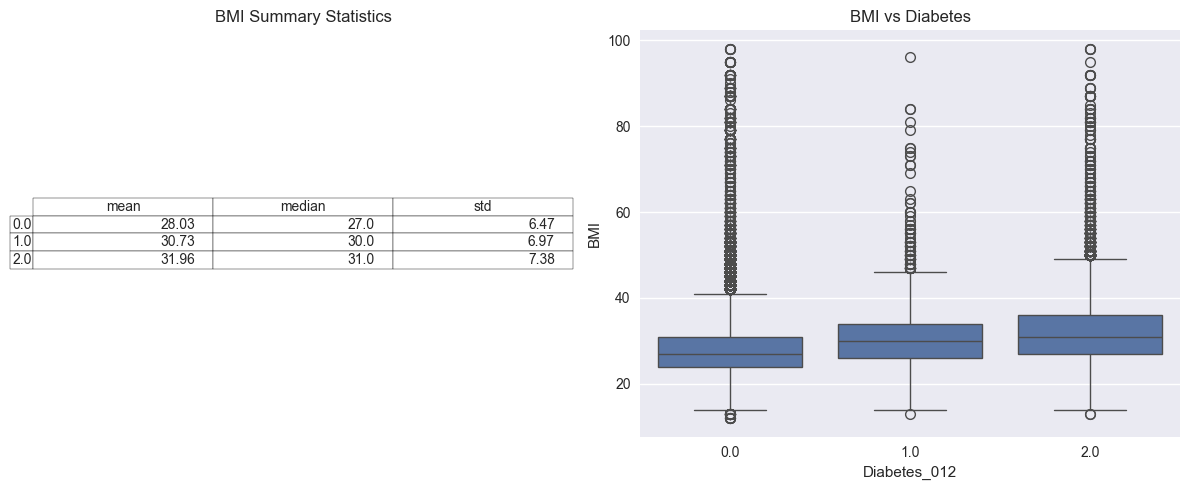

In [85]:
# BMI vs Diabetes
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Graph
sns.boxplot(x='Diabetes_012', y='BMI', data=df, ax=axes[1])
axes[1].set_title("BMI vs Diabetes")

# Table
summary = df.groupby('Diabetes_012')['BMI'].agg(['mean', 'median', 'std'])
axes[0].axis('off')
axes[0].table(
    cellText=summary.round(2).values,
    colLabels=summary.columns,
    rowLabels=summary.index,
    loc='center'
)

axes[0].set_title("BMI Summary Statistics")

plt.tight_layout()

plt.savefig(f"{fig_path}/bmi_vs_diabetes.png", dpi=300, bbox_inches='tight')
plt.show()

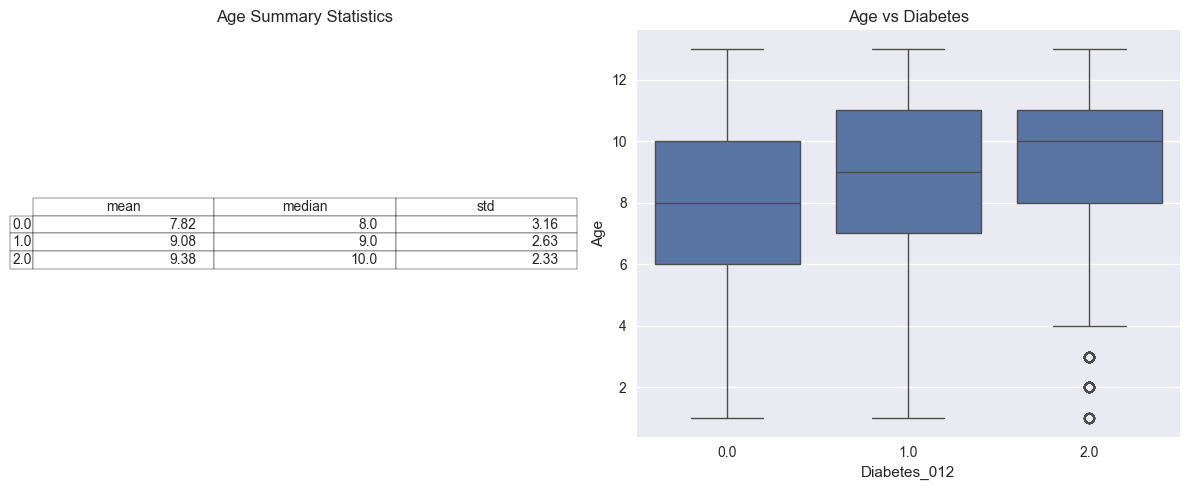

In [86]:
# Age vs Diabetes

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Graph
sns.boxplot(x='Diabetes_012', y='Age', data=df, ax=axes[1])
axes[1].set_title("Age vs Diabetes")

# Table
summary = df.groupby('Diabetes_012')['Age'].agg(['mean', 'median', 'std'])
axes[0].axis('off')
axes[0].table(
    cellText=summary.round(2).values,
    colLabels=summary.columns,
    rowLabels=summary.index,
    loc='center'
)

axes[0].set_title("Age Summary Statistics")

plt.tight_layout()

plt.savefig(f"{fig_path}/age_vs_diabetes.png", dpi=300, bbox_inches='tight')
plt.show()

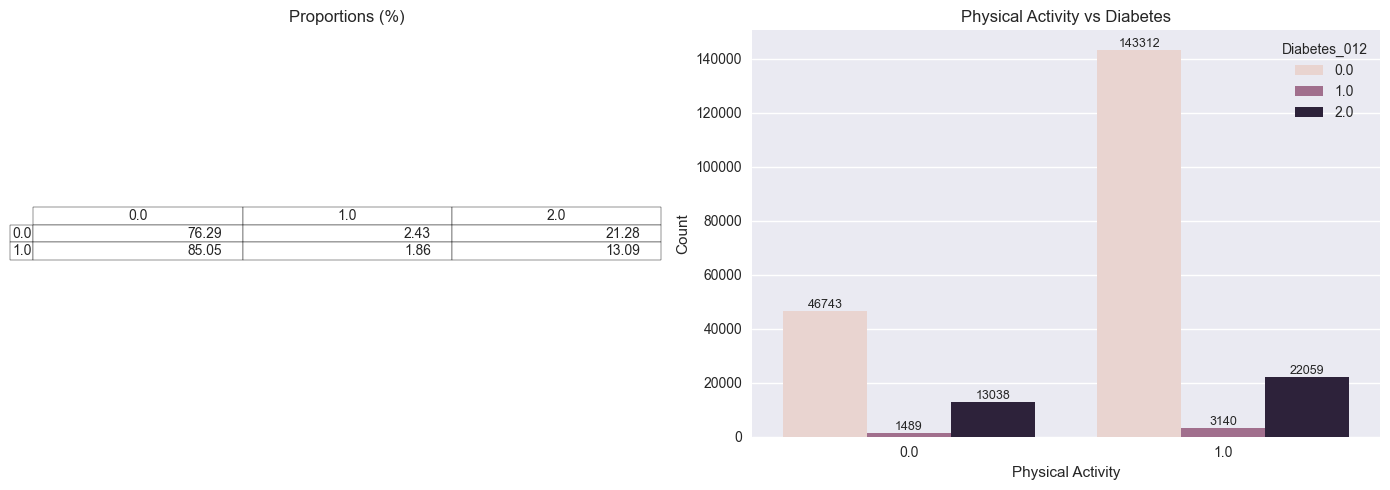

In [87]:
# Physical activity vs Diabetes

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Graph
ax = sns.countplot(x='PhysActivity', hue='Diabetes_012', data=df, ax=axes[1])
axes[1].set_title("Physical Activity vs Diabetes")
axes[1].set_xlabel("Physical Activity")
axes[1].set_ylabel("Count")

# Ajouter les valeurs sur les barres (version correcte avec hue)
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

# Table (percentages)
table = pd.crosstab(df['PhysActivity'], df['Diabetes_012'], normalize='index') * 100
axes[0].axis('off')
axes[0].table(
    cellText=table.round(2).values,
    colLabels=table.columns,
    rowLabels=table.index,
    loc='center'
)

axes[0].set_title("Proportions (%)")

plt.tight_layout()

plt.savefig(f"{fig_path}/PhysicalActivity_vs_diabetes.png", dpi=300, bbox_inches='tight')
plt.show()

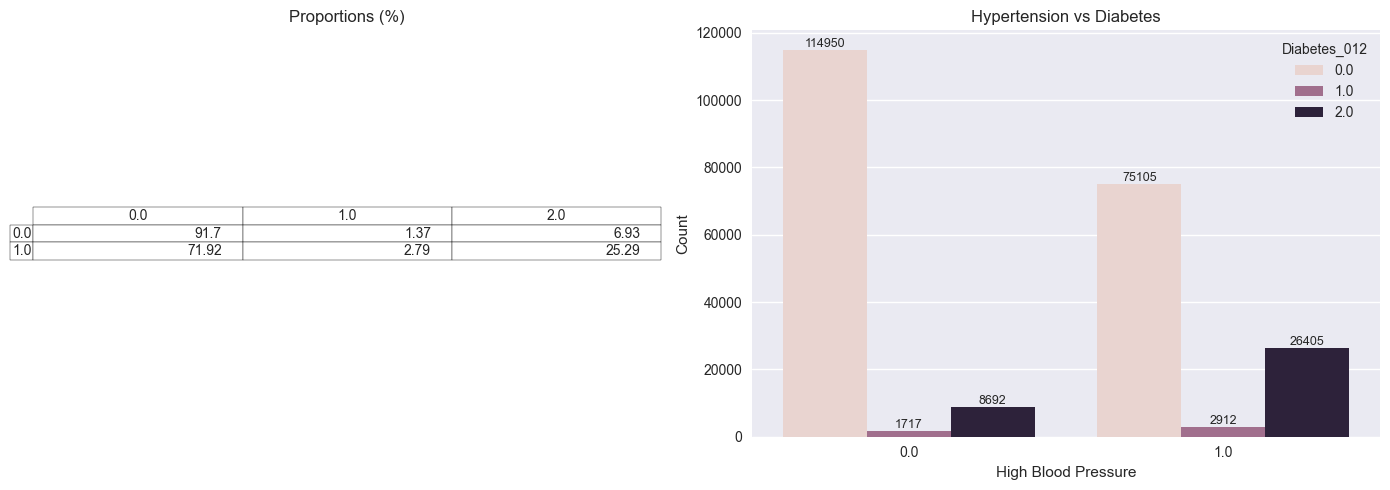

In [88]:
# Hypertension vs Diabetes

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Graph
ax = sns.countplot(x='HighBP', hue='Diabetes_012', data=df, ax=axes[1])
axes[1].set_title("Hypertension vs Diabetes")
axes[1].set_xlabel("High Blood Pressure")
axes[1].set_ylabel("Count")

# Ajouter les valeurs sur les barres (version correcte avec hue)
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

# Table (percentages)
table = pd.crosstab(df['HighBP'], df['Diabetes_012'], normalize='index') * 100
axes[0].axis('off')
axes[0].table(
    cellText=table.round(2).values,
    colLabels=table.columns,
    rowLabels=table.index,
    loc='center'
)

axes[0].set_title("Proportions (%)")

plt.tight_layout()

plt.savefig(f"{fig_path}/hypertension_vs_diabetes.png", dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# CORRELATION ANALYSIS

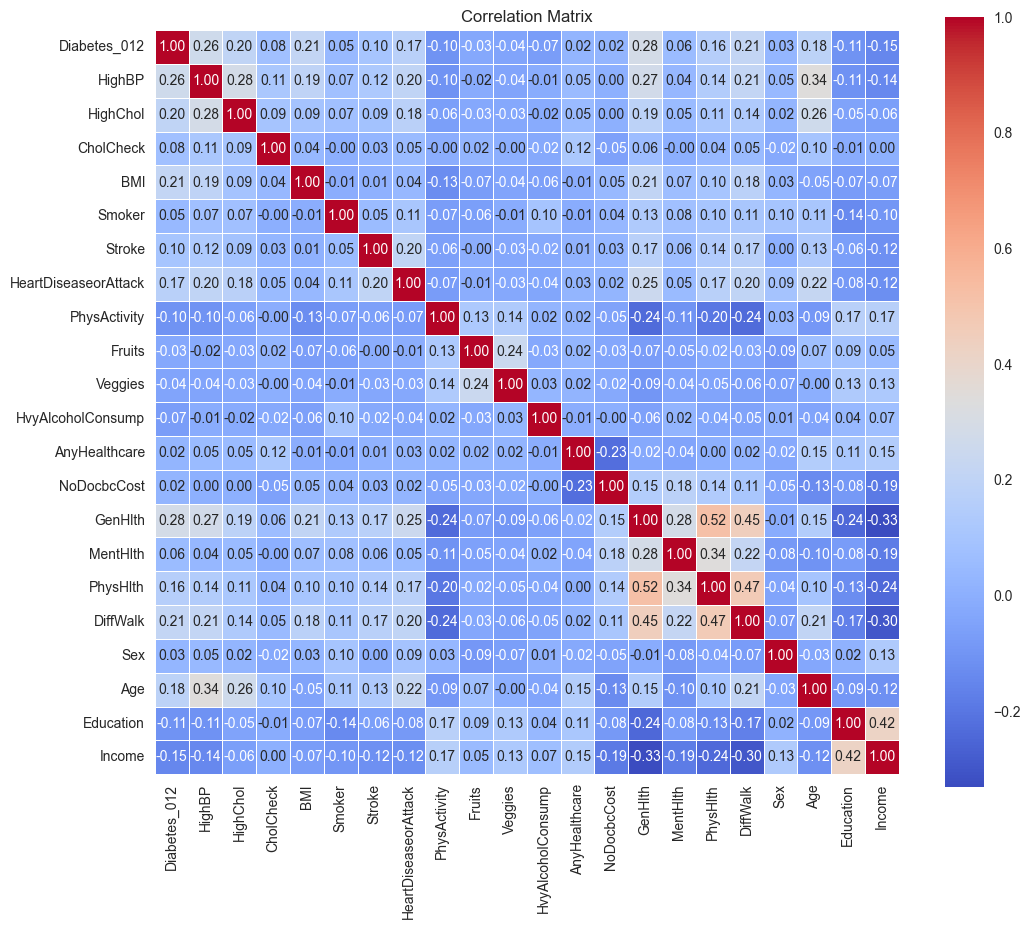

In [89]:
plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix")

plt.savefig(f"{fig_path}/correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_42480\3184228880.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"{fig_path}/high_risk_profiles.png",


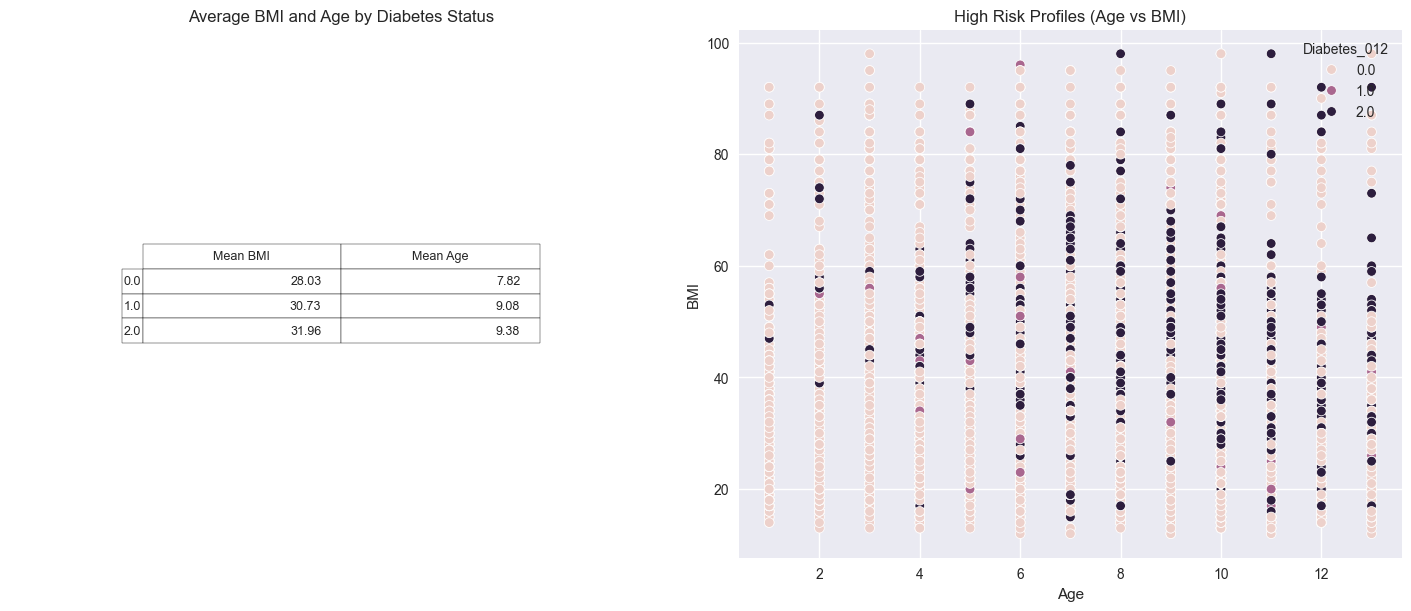

In [99]:
# HIGH-RISK PROFIL

# Tableau des moyennes
summary = df.groupby('Diabetes_012')[['BMI', 'Age']].mean().round(2)

fig, axes = plt.subplots(1, 2, figsize=(14,6), constrained_layout=True)

# Scatterplot
sns.scatterplot(
    x='Age',
    y='BMI',
    hue='Diabetes_012',
    data=df,
    
)

axes[1].set_title("High Risk Profiles (Age vs BMI)")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("BMI")

# Tableau
axes[0].axis('off')

table = axes[0].table(
    cellText=summary.values,
    colLabels=["Mean BMI", "Mean Age"],
    rowLabels=summary.index,
    loc='center',
    colWidths=[0.3, 0.3]
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)

axes[0].set_title("Average BMI and Age by Diabetes Status")

# Save
plt.savefig(f"{fig_path}/high_risk_profiles.png",
            dpi=300, bbox_inches='tight')

plt.show()


In [45]:
df.groupby('Diabetes_012')[['BMI', 'Age']].mean()

,BMI,Age
Diabetes_012,,
0.0,28.030528,7.824230
1.0,30.726075,9.082091
2.0,31.964242,9.375958
